<a href="https://colab.research.google.com/github/faishal-ai/machine-learning_2025/blob/main/ML_P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#*JS04 - Klasterisasi*

# PRAKTIKUM 1

# Langkah 1 - Import Library

In [75]:
# Import required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

langkah pertama mengimport library yang akan di gunakan

# Langkah 2 - Load dan Inspeksi Data

In [76]:
df = pd.read_csv('/content/sample_data/Iris.csv')
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


membaca file menggunakan pd.read untuk membaca file iris.csv yg di upload di folder lalu menampilkan menggunakan df.head() untuk menampilkan 5 pertama

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


menggunakan df.info untuk melihat apakah ada missing velaue

# Langkah 3 - Seleksi Fitur

In [78]:
# Features Selection
X = df.iloc[:, 1:-1] # slice the features
y = df.iloc[:, -1] # this is the labels (we don't need it)

In [79]:
print(X.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


Kode ini memisahkan data mentah (df) jadi dua bagian wajib dalam ML: Fitur/Input (X) dan Target/Label (y). Kemudian, dia mencetak preview dari fitur (X.head()) untuk memastikan bahwa kolom-kolom yang gak penting (ID di awal) dan label (di akhir) sudah berhasil dikeluarkan dari set fitur.

# Langkah 4 - Plotting

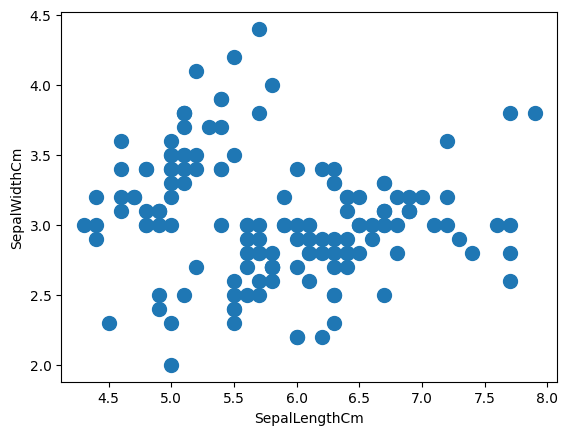

In [80]:
# Make a scatterplot using
# SepalLengthCm and SepalWidthCm
plt.xlabel('SepalLengthCm')
plt.ylabel('SepalWidthCm')
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

Kode ini membuat sebuah grafik sebar (scatter plot) yang memvisualisasikan hubungan antara dua fitur pertama dari dataset, yaitu SepalLengthCm (Panjang Kelopak) pada sumbu X dan SepalWidthCm (Lebar Kelopak) pada sumbu Y. Setiap titik pada plot merepresentasikan satu data bunga, dan ukuran titik (s=100) sengaja dibuat lebih besar agar lebih jelas.

# Langkah 5 - Membuat Model K-Means

In [81]:
# Build a K-Means Model
# Based on visual inspection using scatterplot,
# we can assumpt that the data has 2 cluster
# (even though, from the label, there are 3 labels in this data)

from sklearn.cluster import KMeans

# Initiate K-Means object with numbur of cluster is 2
cl_kmeans = KMeans(n_clusters=2)

# Fit and predict
y_kmeans = cl_kmeans.fit_predict(X)

KMeans(n_clusters=2): Objek K-Means dibuat dengan parameter kunci n_clusters yang diset ke 2. Ini secara eksplisit memerintahkan algoritma untuk mencari dan membuat 2 kluster dari data yang ada.

cl_kmeans.fit_predict(X): Model langsung fit (belajar dari data X) dan predict (memberikan label kluster untuk setiap titik data) dalam satu baris perintah. Hasil label kluster ini disimpan di variabel y_kmeans.

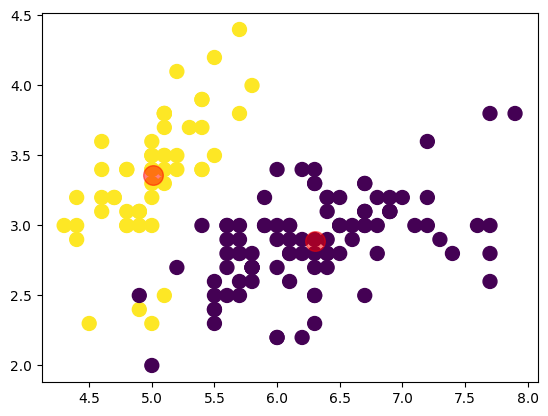

In [82]:
# Plot the clustering result
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot the centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

Plot ini memberikan validasi visual langsung: kita bisa melihat apakah pembagian 2 kluster sudah masuk akal secara spasial, dan seberapa baik kedua Centroid tersebut memposisikan diri untuk memisahkan dan mewakili kedua kelompok data tersebut. Hasilnya menunjukkan model 2 kluster yang siap dianalisis lebih lanjut.

# Langkah 6 - Evaluasi Model

In [83]:
# Print SSE value
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


bertujuan untuk menampilkan nilai SSE (Sum of Squared Errors), yang dalam Scikit-learn disebut Inertia.

SSE / Inertia adalah metrik kunci yang mengukur seberapa "padu" (cohesive) kluster yang telah dibentuk.



# Langkah 7 - Menentukan k terbaik dengan Elbow Method

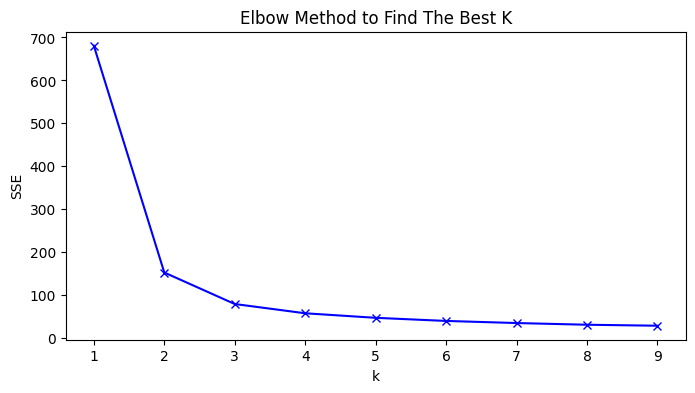

In [84]:
# Find the best k
# using Elbow Method

# List SSE values
sse = []

# Build k range from 1 to 9
K = range(1,10)

# Find the SSE value for each k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)

# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Elbow Method to Find The Best K")
plt.show()

setelah melihat plot, k terbaik akan dipilih sebagai titik "siku" tersebut. Secara historis dan berdasarkan konteks data Iris yang umum, titik "siku" ini sering terjadi pada k=3, meskipun perlu dilihat lagi plot spesifik yang dihasilkan.

# PRAKTIKUM 2

# Langkah 0 - Import Library

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Langkah 1 - Membuat Dataset Sintentis

In [86]:
from sklearn.datasets import make_moons

X, y = make_moons(200, noise=.05, random_state=0)

X, y = make_moons(...): Ini menghasilkan dua array utama:

X: Berisi 200 sampel data (titik koordinat fitur) yang akan digunakan sebagai input.

y: Berisi label/target dari masing-masing sampel, yang menunjukkan kelompok aslinya (biasanya 0 dan 1, merepresentasikan dua bulan sabit).

noise=.05: Data yang dibuat memiliki sedikit kebisingan (noise) sebesar 0.05, yang membuat kedua kelompok bulan sabit sedikit tumpang tindih dan tidak sempurna, sehingga simulasi data dunia nyata jadi lebih realistis dan menantang.

random_state=0: Ini memastikan bahwa setiap kali kode dijalankan, hasilnya konsisten (titik-titik data berada di posisi yang sama), sehingga eksperimen Anda dapat direplikasi.

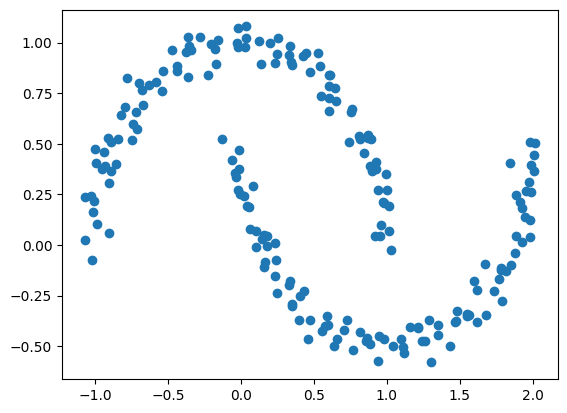

In [87]:
plt.scatter(X[:, 0], X[:, 1])

Kode ini membuat grafik sebar (scatter plot) yang memvisualisasikan data "Moons" sintetis yang baru saja dibuat.

# Langkah 2 - Klasterisasi dengan K-Means

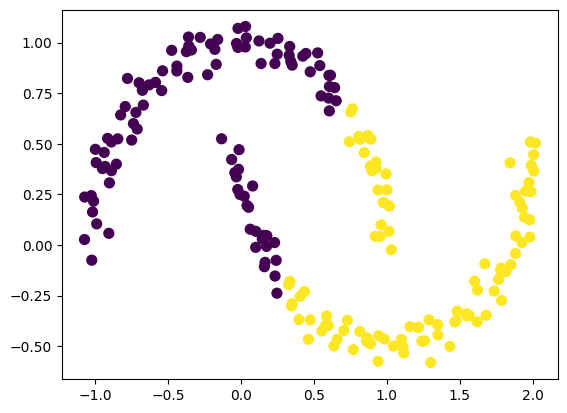

In [88]:
from sklearn.cluster import KMeans

kmeans = KMeans(2, random_state=0)
cluster = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=cluster, s=50, cmap='viridis')

Kode ini mengaplikasikan algoritma K-Means untuk mencoba mengelompokkan data "Moons" yang bentuknya melengkung menjadi dua kluster (k=2), kemudian memvisualisasikan hasilnya.

In [89]:
from sklearn.metrics import silhouette_score

print(silhouette_score(X, cluster))

0.49215648268306905


Kode ini menghitung dan menampilkan Silhouette Score, sebuah metrik kunci untuk mengevaluasi kualitas hasil clustering yang sudah didapatkan oleh model K-Means sebelumnya pada data "Moons".

# Langkah 3 - Klasterisasi dengan DBSCAN

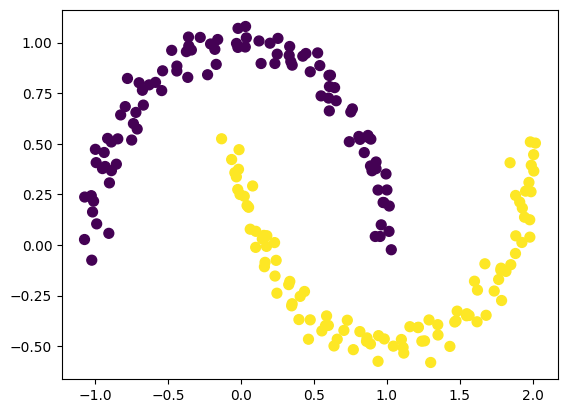

In [90]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=2)
cluster_db = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=cluster_db, s=50, cmap='viridis')

Kode ini mengaplikasikan algoritma DBSCAN (Density-Based Spatial Clustering of Applications with Noise) untuk mengelompokkan data "Moons", yang merupakan tes langsung setelah kegagalan K-Means.

In [91]:
from sklearn.metrics import silhouette_score

print(silhouette_score(X, cluster_db))

# Hasil 0.32585318950197517

0.32585318950197517


Kode ini menghitung Silhouette Score untuk menilai seberapa baik kluster yang dihasilkan oleh algoritma DBSCAN pada data "Moons"


## Davies-Bouldin Index (DBI) --> fokus pada separasi indeks, semakin kecil semakin baik, rentang 0 hingga tak hingga.

In [92]:
from sklearn.metrics import davies_bouldin_score

# Compute and print Davies-Bouldin Index
db = davies_bouldin_score(X, cluster_db)

print(f"Davies-Bouldin Index: {db}")

# Hasilnya
# Davies-Bouldin Index: 1.1622685374061352

Davies-Bouldin Index: 1.1622685374061352


Setelah kode dijalankan, hasilnya (yang berupa satu angka) akan dicetak. Semakin rendah nilai DBI (mendekati 0), semakin baik hasil clustering-nya. Nilai DBI yang rendah menunjukkan kluster yang rapat di dalamnya dan terpisah jauh dari kluster lain.

# PRAKTIKUM 3

# Langkah 0 - Import Library

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Langkah 1 - Load Data Citra

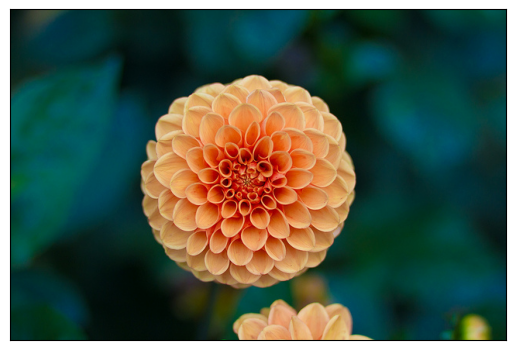

In [94]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower)

Kode ini hanya melakukan tugas loading dan plotting dasar untuk mendapatkan gambar "flower.jpg" sebagai data matriks dan memastikannya bisa divisualisasikan, sering kali sebagai langkah awal sebelum gambar tersebut diproses lebih lanjut (misalnya, di-clustering atau di-resizing).

# Langkah 2 - Preprocessing

In [95]:
# Check shape
print(flower.shape)

# Normalize color
data = flower / 255.0

# Reshape
data = data.reshape(427 * 640, 3) # turn to 1D

print(data.shape)

(427, 640, 3)
(273280, 3)


Kode ini adalah langkah penting dalam persiapan data (preprocessing) gambar sebelum diolah oleh algoritma Machine Learning. Pertama, print(flower.shape) menampilkan dimensi asli gambar (Tinggi, Lebar, Channel RGB), misalnya (427,640,3). Selanjutnya, data = flower / 255.0 melakukan normalisasi warna dengan mengubah rentang nilai piksel dari 0−255 menjadi 0.0−1.0 agar semua channel warna memiliki bobot yang setara. Terakhir, data.reshape(427 * 640, 3) merombak dimensi gambar menjadi matriks 2D dengan format $[$jumlah_piksel, 3] (sekitar 273.280 baris dan 3 kolom), yang secara efektif mengubah data gambar menjadi dataset di mana setiap baris adalah satu sampel piksel yang siap di-clustering berdasarkan nilai warna RGB-nya.

# Langkah 3 - Cek Sebaran Warna

In [96]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

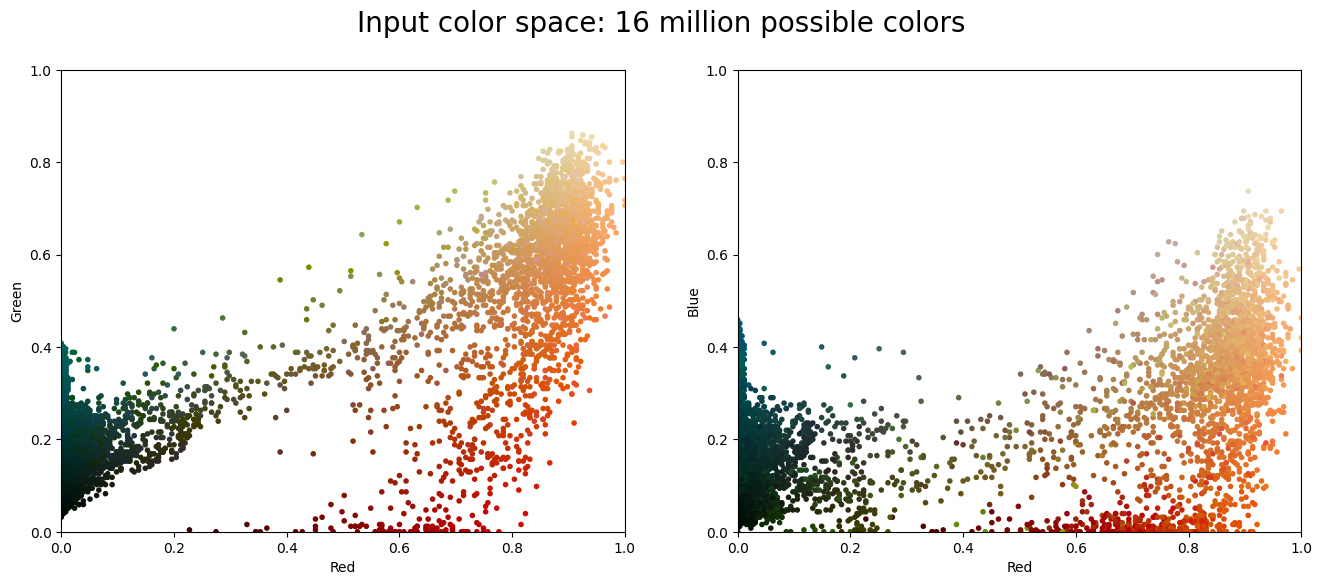

In [97]:
plot_pixels(data, title='Input color space: 16 million possible colors')

Fungsi plot_pixels secara efisien memvisualisasikan distribusi warna gambar. Ia mengambil subset acak 10.000 piksel untuk mempercepat proses. Fungsi ini menampilkan dua scatter plot berdampingan: satu memetakan dimensi Merah vs. Hijau dan satu lagi Merah vs. Biru, dengan setiap titik diwarnai oleh warna aslinya. Tujuannya adalah untuk mengidentifikasi kluster-kluster warna dominan dalam gambar, yang menjadi insight penting sebelum menerapkan K-Means Clustering pada warna piksel.

# Langkah 4 - Klasterisasi Warna

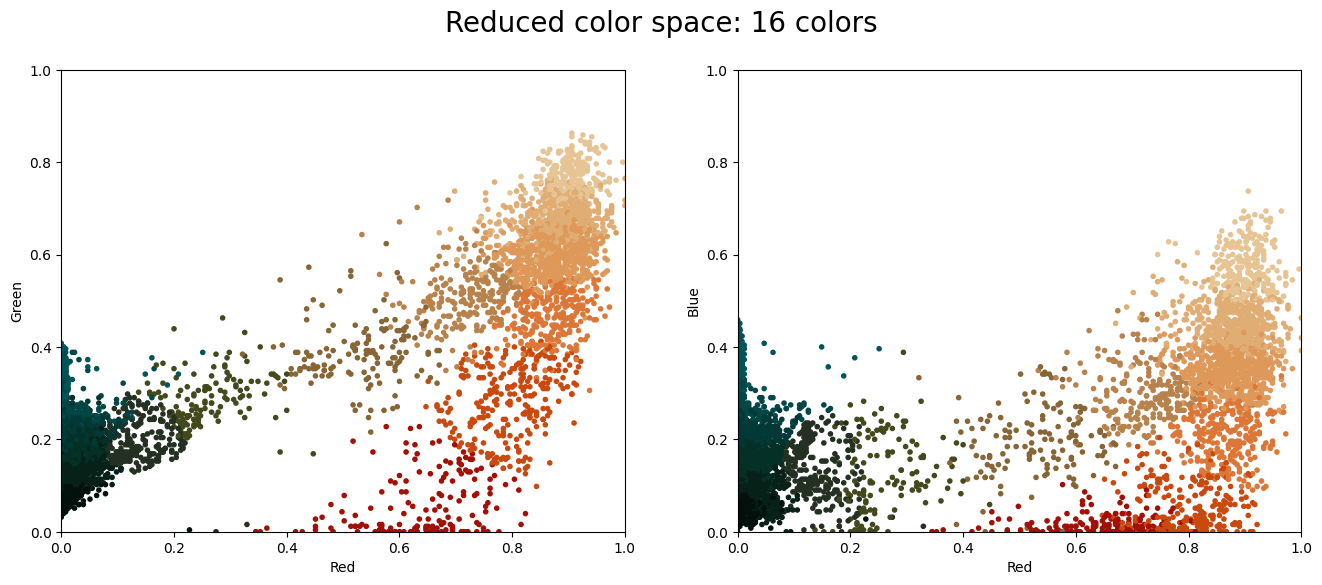

In [98]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

Proses ini berhasil mengurangi kompleksitas ruang warna gambar secara drastis, dari spektrum luas menjadi hanya 16 warna, dengan setiap piksel kini diwakili oleh warna dari kluster terdekatnya. Ini adalah teknik yang biasa digunakan untuk kompresi gambar atau membuat lukisan digital bergaya poster.

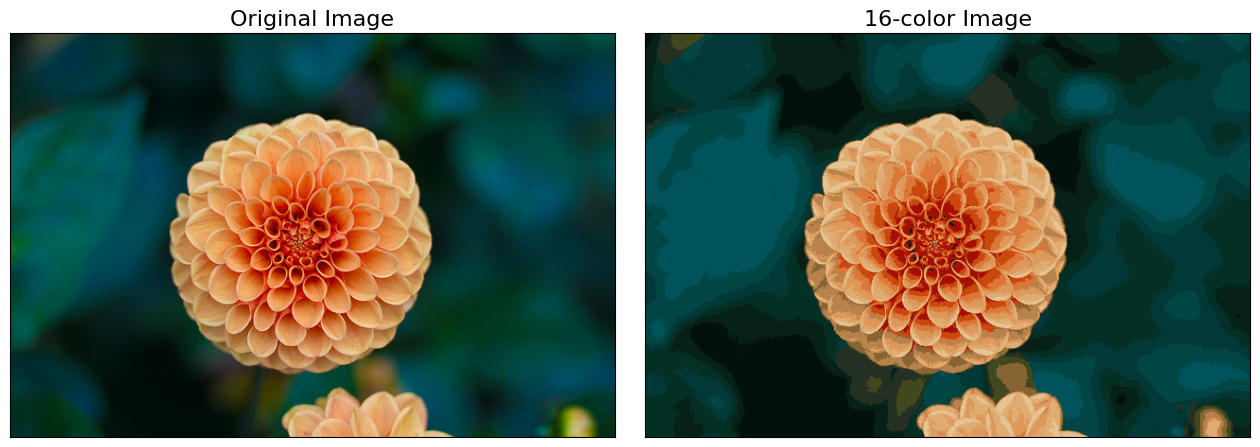

In [99]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

Kode ini adalah langkah terakhir yang bertujuan untuk membandingkan gambar asli dengan gambar yang sudah melalui proses kuantisasi warna (pengurangan warna) menggunakan MiniBatchKMeans.

PRAKTIKUM TUGAS


1.Buatlah scatterplot berdasarkan dataset menggunakan dua variabel, yaitu Avg_Credit_Limit dan Total_credit_card. Apakah sebaran data dapat dikatakan linier?

2.Buatlah model klasterisasi dengan menggunakan model K-Means. Tentukan jumlah
k
k yang terbaik dengan menggunakan elbow method. Lengkapi analisis Anda dengan linechart dan hasil analisis mengapa Anda memilih nilai tersebut.

3.Gambarkan hasil klasterisasi dengan model K-Means dengan menggunakan scatterplot.

4.Buatlah model klasterisasi dengan menggunakan DBSCAN dengan seluruh variabel yang dapat digunakan.

5.Tentukan jumlah
k
k yang terbaik dengan menggunakan elbow method. Lengkapi analisis Anda dengan linechart dan hasil analisis mengapa Anda memilih nilai tersebut.

6.Tentukan nilai silhouette score dan DBI dari model DBSCAN.

# 1.Buatlah scatterplot berdasarkan dataset menggunakan dua variabel, yaitu Avg_Credit_Limit dan Total_credit_card. Apakah sebaran data dapat dikatakan linier?

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [101]:
df = pd.read_csv("/content/sample_data/Mall_Customers.csv")

print("Info Dataset:")
print(df.info())
print("\n5 data pertama:")
print(df.head())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

5 data pertama:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


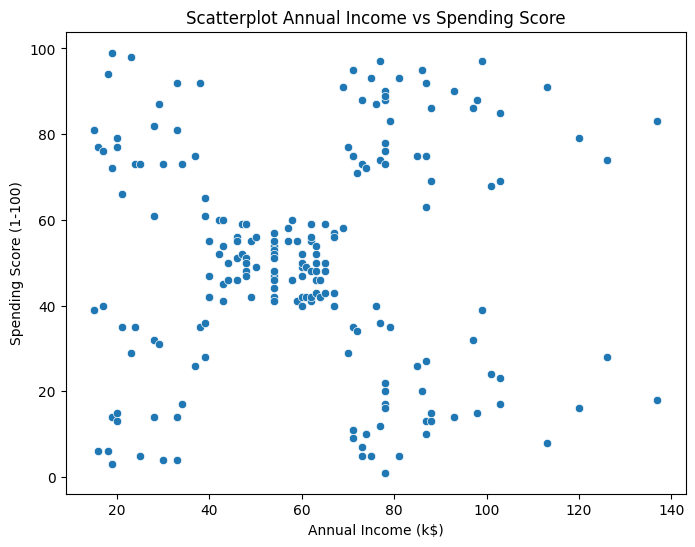

In [102]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)")
plt.title("Scatterplot Annual Income vs Spending Score")
plt.show()

# 2.Buatlah model klasterisasi dengan menggunakan model K-Means. Tentukan jumlah k k yang terbaik dengan menggunakan elbow method. Lengkapi analisis Anda dengan linechart dan hasil analisis mengapa Anda memilih nilai tersebut.

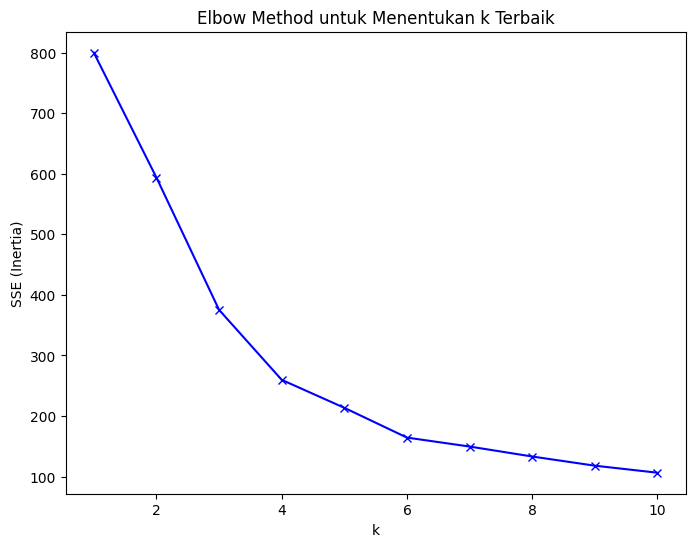

In [103]:
# Pilih fitur numerik (drop kolom non numerik seperti ID jika ada)
features = df.select_dtypes(include=[np.number])

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

sse = []
K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,6))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method untuk Menentukan k Terbaik")
plt.show()

# 3.Gambarkan hasil klasterisasi dengan model K-Means dengan menggunakan scatterplot.

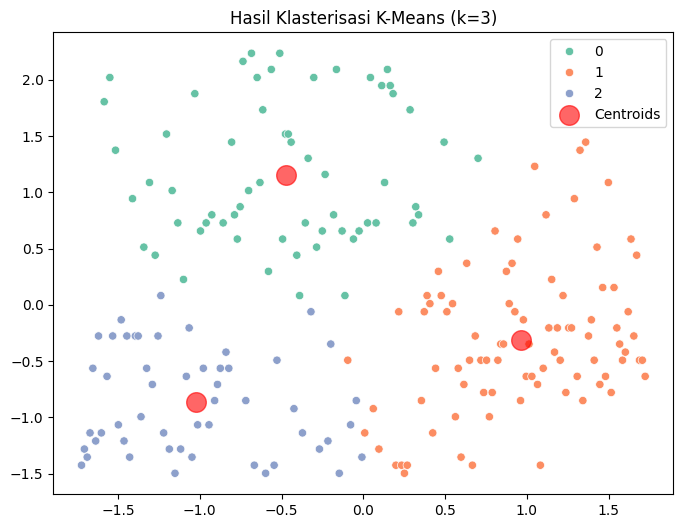

In [104]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=y_kmeans, palette="Set2")
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c="red", s=200, alpha=0.6, label="Centroids")
plt.title(f"Hasil Klasterisasi K-Means (k={k_opt})")
plt.legend()
plt.show()

# 4.Buatlah model klasterisasi dengan menggunakan DBSCAN dengan seluruh variabel yang dapat digunakan.

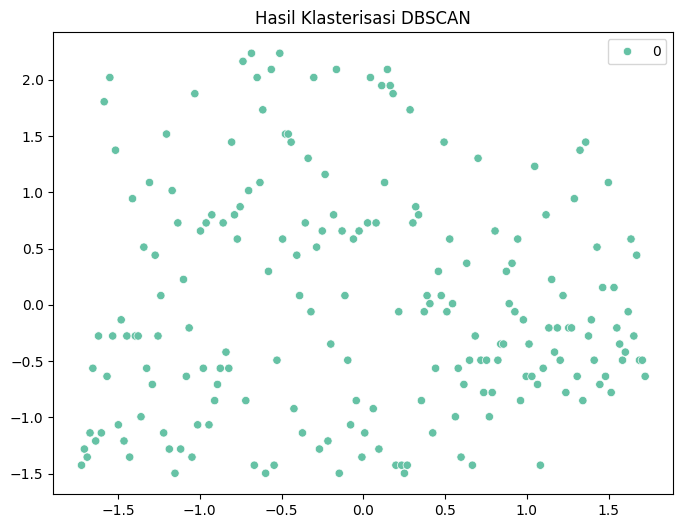

In [105]:
dbscan = DBSCAN(eps=1.5, min_samples=5)   # parameter bisa disesuaikan
cluster_db = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=cluster_db, palette="Set2")
plt.title("Hasil Klasterisasi DBSCAN")
plt.show()


# 5.Tentukan jumlah k k yang terbaik dengan menggunakan elbow method. Lengkapi analisis Anda dengan linechart dan hasil analisis mengapa Anda memilih nilai tersebut.

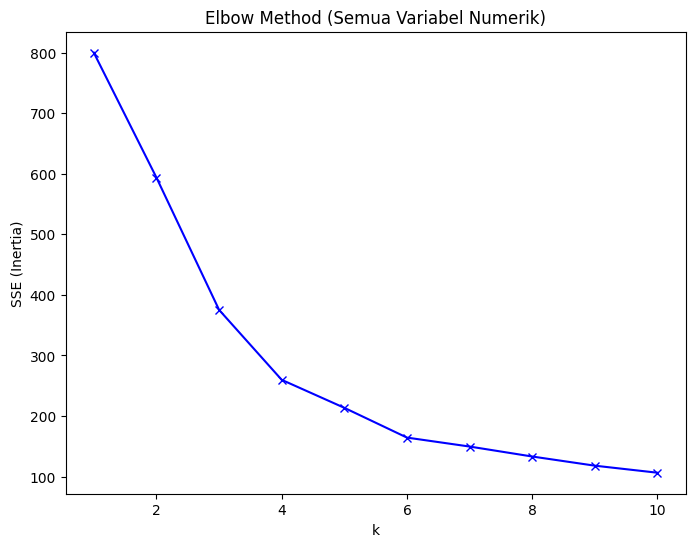

In [106]:
sse2 = []
K2 = range(1,11)
for k in K2:
    kmeans2 = KMeans(n_clusters=k, random_state=0)
    kmeans2.fit(X_scaled)
    sse2.append(kmeans2.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K2, sse2, "bx-")
plt.xlabel("k")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method (Semua Variabel Numerik)")
plt.show()


# 6.Tentukan nilai silhouette score dan DBI dari model DBSCAN.

In [107]:
if len(set(cluster_db)) > 1 and len(set(cluster_db)) != 1:
    sil = silhouette_score(X_scaled, cluster_db)
    dbi = davies_bouldin_score(X_scaled, cluster_db)
    print(f"Silhouette Score (DBSCAN): {sil}")
    print(f"Davies-Bouldin Index (DBSCAN): {dbi}")
else:
    print("DBSCAN hanya menghasilkan 1 cluster atau noise semua, silhouette & DBI tidak bisa dihitung.")

DBSCAN hanya menghasilkan 1 cluster atau noise semua, silhouette & DBI tidak bisa dihitung.
